In [1]:
# IMPORTACIÓN DE LIBRERÍAS

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# DEFINICIÓN DE RUTAS

PROCESSED = Path("../data/processed")
DOCS = Path("../docs")
FIGURES = DOCS / "figures"

PROCESSED.mkdir(parents=True, exist_ok=True)
DOCS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Datos procesados:", PROCESSED.resolve())
print("Figuras:", FIGURES.resolve())

Datos procesados: C:\Users\sebxs29\Documents\Universidad\Semestre_3_2026_A\Analisis_Datos\proyecto-accidentes-transito\data\processed
Figuras: C:\Users\sebxs29\Documents\Universidad\Semestre_3_2026_A\Analisis_Datos\proyecto-accidentes-transito\docs\figures


In [4]:
# CARGA DE DATOS PROCESADOS

siniestros = pd.read_csv(
    PROCESSED / "siniestros_2019_limpio.csv",
    encoding="utf-8-sig"
)

vehiculos = pd.read_csv(
    PROCESSED / "vehiculos_matriculados_2019_limpio.csv",
    encoding="utf-8-sig"
)

precipitacion = pd.read_csv(
    PROCESSED / "precipitacion_2019_limpia.csv",
    encoding="utf-8-sig"
)

temperatura = pd.read_csv(
    PROCESSED / "temperatura_2019_limpia.csv",
    encoding="utf-8-sig"
)

fallecidos = pd.read_csv(
    PROCESSED / "fallecidos_sppat_2019_limpio.csv",
    encoding="utf-8-sig"
)

poblacion = pd.read_csv(
    PROCESSED / "poblacion_censo_2022_limpia.csv",
    encoding="utf-8-sig"
)

print("Datos procesados cargados correctamente.")

Datos procesados cargados correctamente.


In [5]:
# DICCIONARIO DE DATASETS

datasets_eda = {
    "siniestros": siniestros,
    "vehiculos": vehiculos,
    "precipitacion": precipitacion,
    "temperatura": temperatura,
    "fallecidos": fallecidos,
    "poblacion": poblacion
}

In [6]:
# RESUMEN DE DIMENSIONES

resumen_datasets = pd.DataFrame([
    {
        "dataset": nombre,
        "filas": df.shape[0],
        "columnas": df.shape[1]
    }
    for nombre, df in datasets_eda.items()
])

resumen_datasets

,dataset,filas,columnas
0,siniestros,23777,20
1,vehiculos,2311960,11
2,precipitacion,216,9
3,temperatura,216,9
4,fallecidos,3170,12
5,poblacion,1042,6


In [7]:
# COLUMNAS DE CADA DATASET

for nombre, df in datasets_eda.items():
    print("=" * 70)
    print(nombre.upper())
    print("=" * 70)
    print(df.columns.tolist())
    print()

SINIESTROS
['mes', 'dia', 'hora', 'provincia', 'canton', 'zona', 'num_fallecido', 'num_lesionado', 'total_victimas', 'clase', 'causa', 'mes_num', 'dia_semana_num', 'hora_num', 'franja_horaria', 'anio', 'fecha_mes', 'total_victimas_calculado', 'total_victimas_inconsistente', 'id_siniestro']

VEHICULOS
['provincia', 'marca', 'clase', 'pasajeros', 'tonelaje', 'combustible', 'modelo', 'servicio', 'estratone', 'estrapasajero', 'anio']

PRECIPITACION
['estacion', 'nombreestacion', 'longitud2', 'latitud2', 'altitud', 'anio', 'mes', 'precipitacion', 'mes_num']

TEMPERATURA
['estacion', 'nombreestacion', 'longitud2', 'latitud2', 'altitud', 'anio', 'mes', 'temperatura', 'mes_num']

FALLECIDOS
['no_', 'genero_de_la_victima', 'estado_civil_de_la_victima', 'condicion', 'fecha_de_muerte_victima', 'tipo_de_accidente', 'fecha_siniestro', 'canton', 'provincia', 'fecha_de_creacion_de_proteccion_de_fallecidos', 'anio', 'mes_num']

POBLACION
['provincia', 'canton', 'parroquia', 'poblacion', 'superficie_de

In [8]:
# PRIMERAS FILAS DE CADA DATASET

for nombre, df in datasets_eda.items():
    print("=" * 70)
    print(nombre.upper())
    print("=" * 70)
    display(df.head())

SINIESTROS


,mes,dia,hora,provincia,canton,zona,num_fallecido,num_lesionado,total_victimas,clase,causa,mes_num,dia_semana_num,hora_num,franja_horaria,anio,fecha_mes,total_victimas_calculado,total_victimas_inconsistente,id_siniestro
0,ENERO,MARTES,11:00 A 11:59,IMBABURA,OTAVALO,URBANA,0,0,0,PERDIDA DE PISTA,IMPERICIA E IMPRUDENCIA DEL CONDUCTOR,1,2,11,MANANA,2019,2019-01-01,0,False,1
1,ENERO,MARTES,23:00 A 23:59,IMBABURA,IBARRA,RURAL,0,0,0,OTROS,OTRAS CAUSAS,1,2,23,NOCHE,2019,2019-01-01,0,False,2
2,ENERO,MARTES,12:00 A 12:59,TUNGURAHUA,AMBATO,URBANA,0,3,3,CHOQUES,NO RESPETA LAS SENALES DE TRANSITO,1,2,12,TARDE,2019,2019-01-01,3,False,3
3,ENERO,MARTES,07:00 A 07:59,TUNGURAHUA,AMBATO,RURAL,0,1,1,ATROPELLOS,EMBRIAGUEZ O DROGA,1,2,7,MANANA,2019,2019-01-01,1,False,4
4,ENERO,MARTES,04:00 A 04:59,PICHINCHA,DISTRITO METROPOLITANO DE QUITO,URBANA,0,0,0,ESTRELLAMIENTOS,EXCESO VELOCIDAD,1,2,4,MADRUGADA,2019,2019-01-01,0,False,5


VEHICULOS


,provincia,marca,clase,pasajeros,tonelaje,combustible,modelo,servicio,estratone,estrapasajero,anio
0,AZUAY,YAMAHA,MOTOCICLETA,1,0.25,GASOLINA,2003 Y ANOS ANTERIORES,PARTICULAR,1/4 A 3,1 A 10,2019
1,AZUAY,YAMAHA,MOTOCICLETA,1,0.25,GASOLINA,2003 Y ANOS ANTERIORES,PARTICULAR,1/4 A 3,1 A 10,2019
2,AZUAY,HONDA,MOTOCICLETA,1,0.25,GASOLINA,2003 Y ANOS ANTERIORES,PARTICULAR,1/4 A 3,1 A 10,2019
3,AZUAY,GEELY,MOTOCICLETA,1,0.25,GASOLINA,2003 Y ANOS ANTERIORES,PARTICULAR,1/4 A 3,1 A 10,2019
4,AZUAY,HONDA,MOTOCICLETA,1,0.25,GASOLINA,2004,PARTICULAR,1/4 A 3,1 A 10,2019


PRECIPITACION


...

,estacion,nombreestacion,longitud2,latitud2,altitud,anio,mes,temperatura,mes_num
0,M0001,INGUINCHO,"-78,408.00",0.26,3140,2019,ene,11.20,1
1,M0002,LA TOLA,-78.37,-0.23,2480,2019,ene,16.30,1
2,M0003,IZOBAMBA,"-78,555.00",-0.37,3058,2019,ene,12.90,1
3,M0004,RUMIPAMBA-SALCEDO,-78.59,-1.02,2685,2019,ene,15.00,1
4,M0005,PORTOVIEJO-UTM,-80.46,-1.04,46,2019,ene,26.20,1


FALLECIDOS


,no_,genero_de_la_victima,estado_civil_de_la_victima,condicion,fecha_de_muerte_victima,tipo_de_accidente,fecha_siniestro,canton,provincia,fecha_de_creacion_de_proteccion_de_fallecidos,anio,mes_num
0,929,MASCULINO,SOLTERO/A,PEATON,2019-01-18,ATROPELLO,2019-01-17,QUITO,PICHINCHA,2021-08-04,2019,1
1,1419,MASCULINO,SOLTERO/A,OCUPANTE,2020-10-24,CHOQUE,2019-12-22,RIOBAMBA,CHIMBORAZO,2021-06-10,2019,12
2,1978,MASCULINO,SOLTERO/A,OCUPANTE,2019-12-21,CHOQUE,2019-12-08,PORTOVIEJO,MANABI,2021-03-30,2019,12
3,1983,MASCULINO,SOLTERO/A,OCUPANTE,2019-12-19,VOLCAMIENTO,2019-12-18,CANAR,CANAR,2021-03-30,2019,12
4,2355,FEMENINO,CASADO/A,OCUPANTE,2019-12-15,CHOQUE,2019-12-14,LA LIBERTAD,SANTA ELENA,2021-02-12,2019,12


POBLACION


,provincia,canton,parroquia,poblacion,superficie_de_la_parroquia_km2_,densidad_poblacional
0,AZUAY,CUENCA,CUENCA,"361,524.00",71.68,"5,044.00"
1,AZUAY,CUENCA,BANOS,"21,797.00",251.44,87.00
2,AZUAY,CUENCA,CUMBE,"6,455.00",75.13,86.00
3,AZUAY,CUENCA,CHAUCHA,"1,721.00",380.00,5.00
4,AZUAY,CUENCA,CHECA,"3,204.00",110.86,29.00


In [9]:
# TIPOS DE DATOS

for nombre, df in datasets_eda.items():
    print("=" * 70)
    print(nombre.upper())
    print("=" * 70)
    df.info()
    print()

SINIESTROS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23777 entries, 0 to 23776
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   mes                           23777 non-null  object
 1   dia                           23777 non-null  object
 2   hora                          23777 non-null  object
 3   provincia                     23777 non-null  object
 4   canton                        23777 non-null  object
 5   zona                          23777 non-null  object
 6   num_fallecido                 23777 non-null  int64 
 7   num_lesionado                 23777 non-null  int64 
 8   total_victimas                23777 non-null  int64 
 9   clase                         23777 non-null  object
 10  causa                         23777 non-null  object
 11  mes_num                       23777 non-null  int64 
 12  dia_semana_num                23777 non-null  int64 
 13  hora_

In [11]:
# Siniestros por provincia

#Se calcula el número de siniestros, fallecidos, lesionados y víctimas registrados en cada provincia.

In [12]:
# SINIESTROS POR PROVINCIA

siniestros_por_provincia = (
    siniestros
    .groupby("provincia", as_index=False)
    .agg(
        total_siniestros=("id_siniestro", "nunique"),
        total_fallecidos=("num_fallecido", "sum"),
        total_lesionados=("num_lesionado", "sum"),
        total_victimas=("total_victimas_calculado", "sum")
    )
    .sort_values("total_siniestros", ascending=False)
)

siniestros_por_provincia.head(10)

,provincia,total_siniestros,total_fallecidos,total_lesionados,total_victimas
9,GUAYAS,8853,517,8493,9010
18,PICHINCHA,4757,356,3081,3437
13,MANABI,1694,148,1213,1361
22,TUNGURAHUA,1350,73,712,785
0,AZUAY,1241,82,1092,1174
20,SANTO DOMINGO DE LOS TSACHILAS,1161,78,859,937
12,LOS RIOS,962,178,921,1099
11,LOJA,619,52,426,478
19,SANTA ELENA,600,45,706,751
4,CHIMBORAZO,574,108,299,407


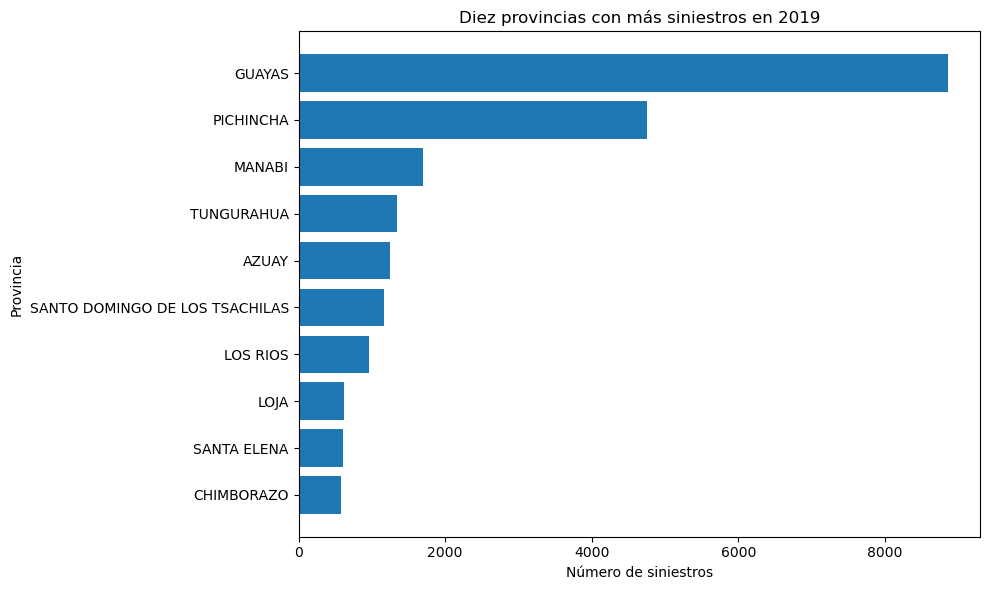

In [13]:
# GRÁFICO: PROVINCIAS CON MÁS SINIESTROS

top_provincias = siniestros_por_provincia.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_provincias["provincia"],
    top_provincias["total_siniestros"]
)

plt.title("Diez provincias con más siniestros en 2019")
plt.xlabel("Número de siniestros")
plt.ylabel("Provincia")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    FIGURES / "siniestros_por_provincia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Siniestros por mes

# Se analiza la distribución mensual de los siniestros, fallecidos, lesionados y víctimas durante 2019.

In [15]:
# SINIESTROS POR MES

siniestros_mensual = (
    siniestros
    .groupby(["mes_num", "mes"], as_index=False)
    .agg(
        total_siniestros=("id_siniestro", "nunique"),
        total_fallecidos=("num_fallecido", "sum"),
        total_lesionados=("num_lesionado", "sum"),
        total_victimas=("total_victimas_calculado", "sum")
    )
    .sort_values("mes_num")
)

siniestros_mensual

,mes_num,mes,total_siniestros,total_fallecidos,total_lesionados,total_victimas
0,1,ENERO,1851,165,1516,1681
1,2,FEBRERO,1875,155,1424,1579
2,3,MARZO,2008,185,1516,1701
3,4,ABRIL,1953,193,1579,1772
4,5,MAYO,1920,174,1673,1847
5,6,JUNIO,2029,173,1657,1830
6,7,JULIO,2030,149,1655,1804
7,8,AGOSTO,2071,188,1846,2034
8,9,SEPTIEMBRE,2017,201,1571,1772
9,10,OCTUBRE,1739,141,1561,1702


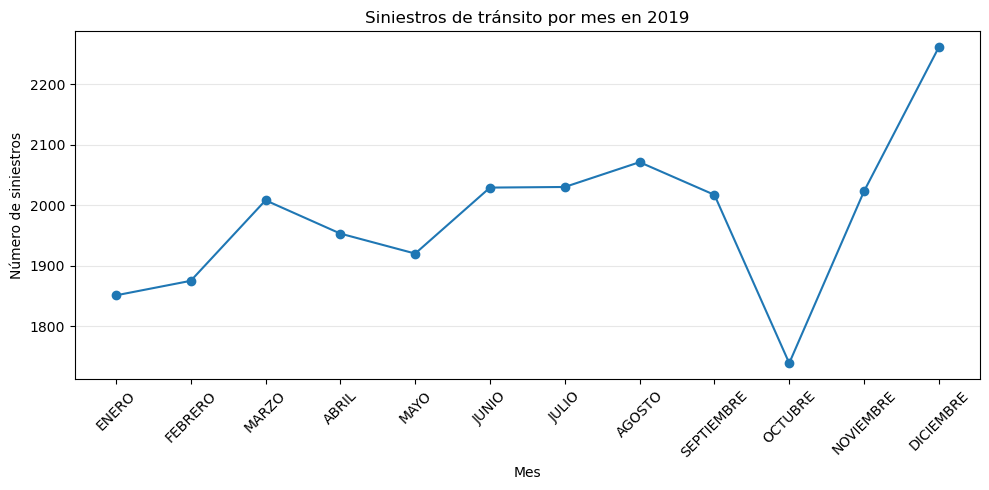

In [16]:
# GRÁFICO: SINIESTROS POR MES

plt.figure(figsize=(10, 5))
plt.plot(
    siniestros_mensual["mes"],
    siniestros_mensual["total_siniestros"],
    marker="o"
)

plt.title("Siniestros de tránsito por mes en 2019")
plt.xlabel("Mes")
plt.ylabel("Número de siniestros")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES / "siniestros_por_mes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
siniestros_mensual.to_csv(
    PROCESSED / "siniestros_mensual.csv",
    index=False,
    encoding="utf-8-sig"
)

In [18]:
# Siniestros por día de la semana

#Se determina qué días de la semana concentran la mayor cantidad de siniestros.

In [19]:
# SINIESTROS POR DÍA DE LA SEMANA

siniestros_por_dia = (
    siniestros
    .groupby(["dia_semana_num", "dia"], as_index=False)
    .agg(
        total_siniestros=("id_siniestro", "nunique"),
        total_fallecidos=("num_fallecido", "sum"),
        total_lesionados=("num_lesionado", "sum")
    )
    .sort_values("dia_semana_num")
)

siniestros_por_dia

,dia_semana_num,dia,total_siniestros,total_fallecidos,total_lesionados
0,1,LUNES,2946,259,2498
1,2,MARTES,2871,217,2309
2,3,MIERCOLES,2764,205,2309
3,4,JUEVES,2843,218,2278
4,5,VIERNES,3545,313,2809
5,6,SABADO,4320,450,3376
6,7,DOMINGO,4488,516,3990


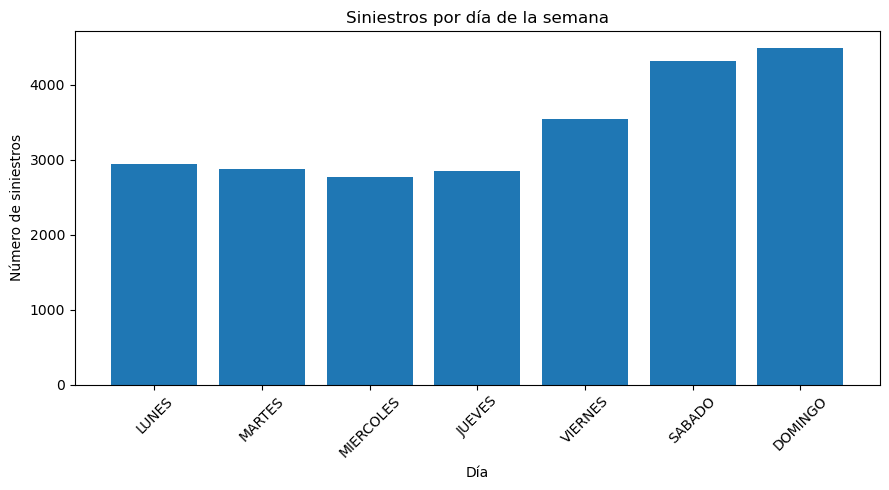

In [20]:
# GRÁFICO: SINIESTROS POR DÍA

plt.figure(figsize=(9, 5))
plt.bar(
    siniestros_por_dia["dia"],
    siniestros_por_dia["total_siniestros"]
)

plt.title("Siniestros por día de la semana")
plt.xlabel("Día")
plt.ylabel("Número de siniestros")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    FIGURES / "siniestros_por_dia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Siniestros por franja horaria

# Se analiza la cantidad de siniestros registrada durante la madrugada, mañana, tarde y noche.

In [22]:
# SINIESTROS POR FRANJA HORARIA

siniestros_por_franja = (
    siniestros
    .groupby("franja_horaria", as_index=False)
    .agg(
        total_siniestros=("id_siniestro", "nunique"),
        total_fallecidos=("num_fallecido", "sum"),
        total_lesionados=("num_lesionado", "sum")
    )
    .sort_values("total_siniestros", ascending=False)
)

siniestros_por_franja

,franja_horaria,total_siniestros,total_fallecidos,total_lesionados
3,TARDE,6686,444,5816
2,NOCHE,6665,714,5592
1,MANANA,5922,421,4999
0,MADRUGADA,4504,599,3162


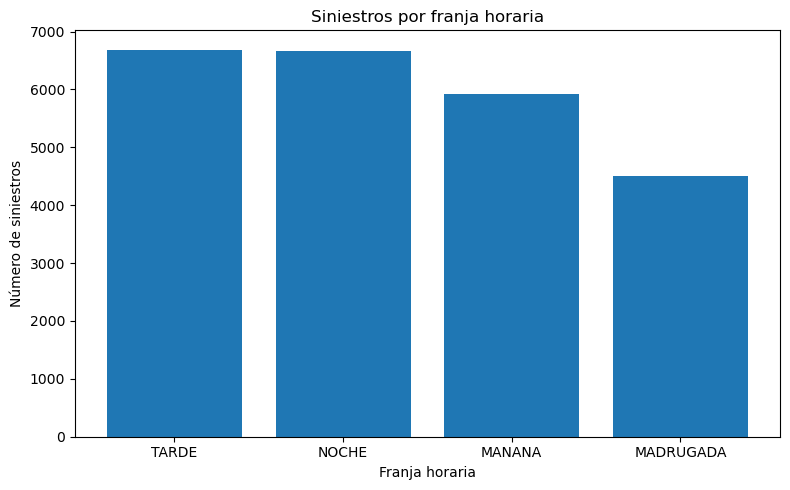

In [23]:
# GRÁFICO: SINIESTROS POR FRANJA HORARIA

plt.figure(figsize=(8, 5))
plt.bar(
    siniestros_por_franja["franja_horaria"],
    siniestros_por_franja["total_siniestros"]
)

plt.title("Siniestros por franja horaria")
plt.xlabel("Franja horaria")
plt.ylabel("Número de siniestros")
plt.tight_layout()

plt.savefig(
    FIGURES / "siniestros_por_franja_horaria.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# Principales causas de los siniestros

# Se identifican las causas registradas con mayor frecuencia durante 2019.

In [25]:
# DIEZ CAUSAS MÁS FRECUENTES

causas_frecuentes = (
    siniestros
    .groupby("causa", as_index=False)
    .agg(
        total_siniestros=("id_siniestro", "nunique"),
        total_fallecidos=("num_fallecido", "sum"),
        total_lesionados=("num_lesionado", "sum")
    )
    .sort_values("total_siniestros", ascending=False)
)

causas_frecuentes.head(10)

,causa,total_siniestros,total_fallecidos,total_lesionados
4,IMPERICIA E IMPRUDENCIA DEL CONDUCTOR,11575,1303,9500
2,EXCESO VELOCIDAD,3680,252,2757
8,NO RESPETA LAS SENALES DE TRANSITO,2979,132,2726
1,EMBRIAGUEZ O DROGA,1776,93,1265
7,MAL REBASAMIENTO INVADIR CARRIL,1724,111,1626
5,IMPRUDENCIA DEL PEATON,1229,147,1118
3,FACTORES CLIMATICOS,230,41,202
6,MAL ESTADO DE LA VIA,220,27,145
9,OTRAS CAUSAS,194,53,120
0,DANOS MECANICOS,170,19,110


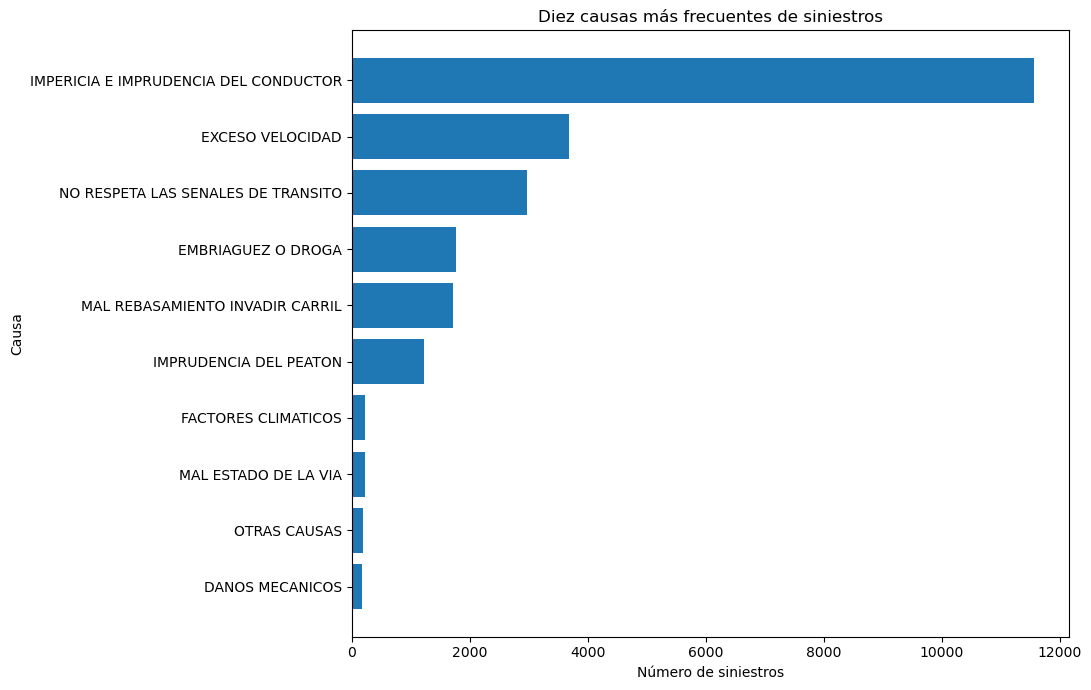

In [26]:
# GRÁFICO: CAUSAS MÁS FRECUENTES

top_causas = causas_frecuentes.head(10)

plt.figure(figsize=(11, 7))
plt.barh(
    top_causas["causa"],
    top_causas["total_siniestros"]
)

plt.title("Diez causas más frecuentes de siniestros")
plt.xlabel("Número de siniestros")
plt.ylabel("Causa")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    FIGURES / "causas_mas_frecuentes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# Clases de accidente más frecuentes

# Se analiza la distribución de los siniestros según la clase de accidente registrada.

In [28]:
# CLASES DE ACCIDENTE MÁS FRECUENTES

clases_frecuentes = (
    siniestros
    .groupby("clase", as_index=False)
    .agg(
        total_siniestros=("id_siniestro", "nunique"),
        total_fallecidos=("num_fallecido", "sum"),
        total_lesionados=("num_lesionado", "sum")
    )
    .sort_values("total_siniestros", ascending=False)
)

clases_frecuentes

,clase,total_siniestros,total_fallecidos,total_lesionados
2,CHOQUES,10981,716,9647
0,ATROPELLOS,3811,630,3544
3,ESTRELLAMIENTOS,3100,211,1465
5,PERDIDA DE PISTA,2997,456,2652
6,ROZAMIENTOS,1220,40,803
1,CAIDA DE PASAJEROS,696,27,694
4,OTROS,558,31,334
7,VOLCAMIENTOS,414,67,430


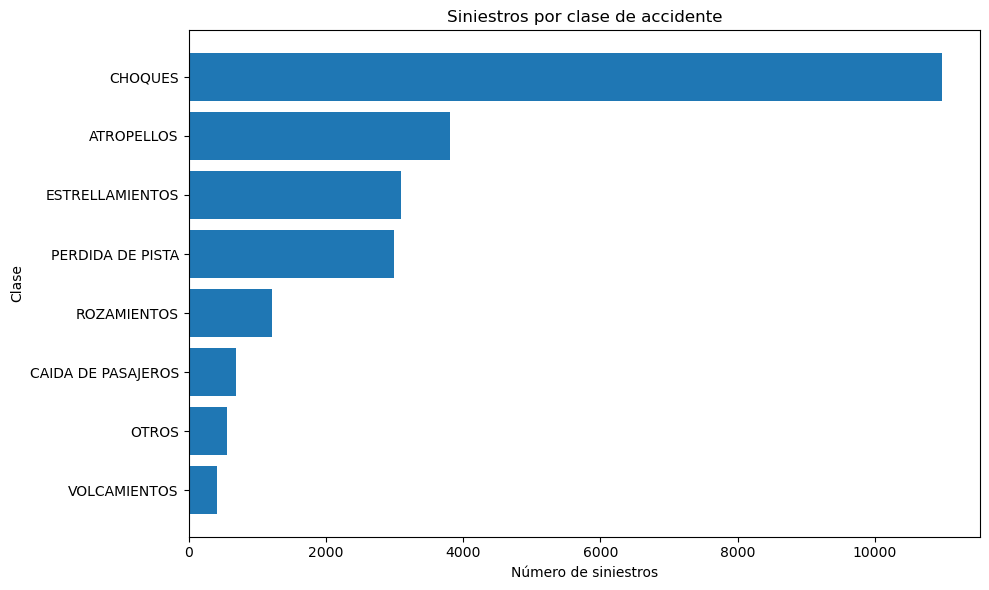

In [29]:
# GRÁFICO: CLASES DE ACCIDENTE

plt.figure(figsize=(10, 6))
plt.barh(
    clases_frecuentes["clase"],
    clases_frecuentes["total_siniestros"]
)

plt.title("Siniestros por clase de accidente")
plt.xlabel("Número de siniestros")
plt.ylabel("Clase")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    FIGURES / "clases_de_accidente.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Fallecidos registrados por provincia

# Cada fila del conjunto SPPAT representa una persona fallecida. Por tanto, el conteo de filas por provincia permite obtener el número de fallecidos registrados.

In [31]:
# FALLECIDOS POR PROVINCIA

fallecidos_por_provincia = (
    fallecidos
    .groupby("provincia", as_index=False)
    .agg(
        total_fallecidos_sppat=("no_", "count")
    )
    .sort_values("total_fallecidos_sppat", ascending=False)
)

fallecidos_por_provincia.head(10)

,provincia,total_fallecidos_sppat
9,GUAYAS,712
18,PICHINCHA,475
12,LOS RIOS,283
13,MANABI,262
4,CHIMBORAZO,153
5,COTOPAXI,145
6,EL ORO,133
22,TUNGURAHUA,129
0,AZUAY,117
20,SANTO DOMINGO DE LOS TSACHILAS,112


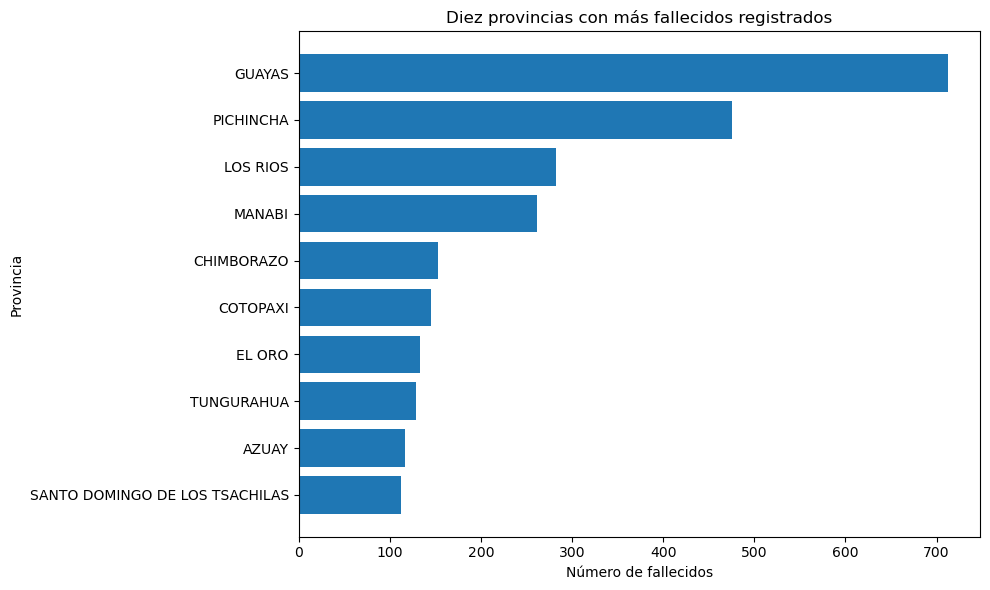

In [32]:
# GRÁFICO: FALLECIDOS POR PROVINCIA

top_fallecidos = fallecidos_por_provincia.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_fallecidos["provincia"],
    top_fallecidos["total_fallecidos_sppat"]
)

plt.title("Diez provincias con más fallecidos registrados")
plt.xlabel("Número de fallecidos")
plt.ylabel("Provincia")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    FIGURES / "fallecidos_por_provincia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
fallecidos_por_provincia.to_csv(
    PROCESSED / "fallecidos_por_provincia.csv",
    index=False,
    encoding="utf-8-sig"
)

In [34]:
# Vehículos matriculados por provincia

# Se cuenta el número de registros vehiculares por provincia. Las repeticiones no se eliminan porque diferentes vehículos pueden compartir las mismas características.

In [35]:
# VEHÍCULOS POR PROVINCIA

vehiculos_por_provincia = (
    vehiculos
    .groupby("provincia", as_index=False)
    .size()
    .rename(columns={"size": "total_vehiculos"})
    .sort_values("total_vehiculos", ascending=False)
)

vehiculos_por_provincia.head(10)

,provincia,total_vehiculos
9,GUAYAS,529908
18,PICHINCHA,521946
13,MANABI,198801
0,AZUAY,145729
12,LOS RIOS,121206
6,EL ORO,112297
22,TUNGURAHUA,101471
20,SANTO DOMINGO DE LOS TSACHILAS,80280
4,CHIMBORAZO,69578
5,COTOPAXI,67665


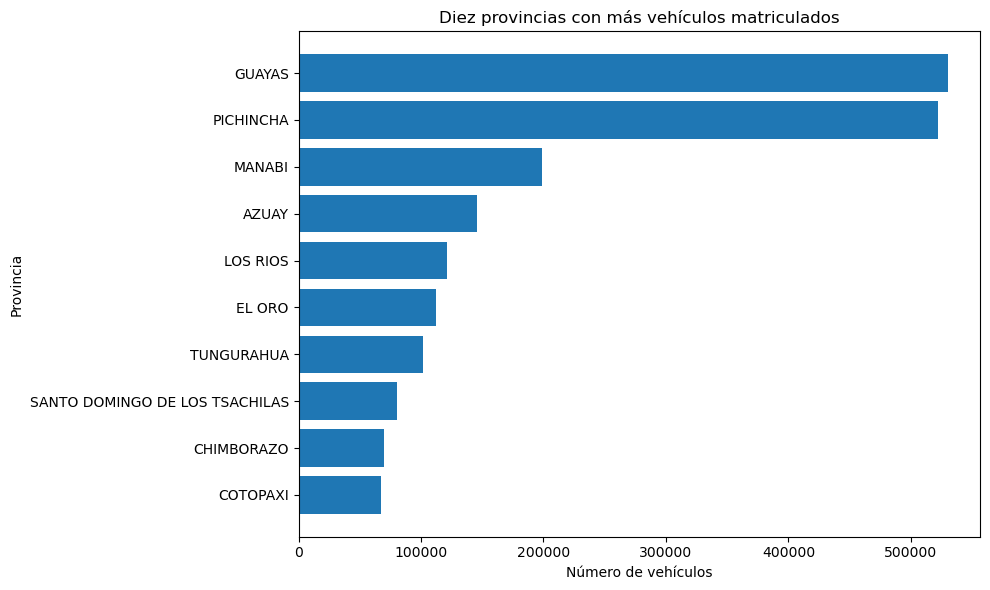

In [36]:
# GRÁFICO: VEHÍCULOS POR PROVINCIA

top_vehiculos = vehiculos_por_provincia.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_vehiculos["provincia"],
    top_vehiculos["total_vehiculos"]
)

plt.title("Diez provincias con más vehículos matriculados")
plt.xlabel("Número de vehículos")
plt.ylabel("Provincia")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    FIGURES / "vehiculos_por_provincia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
vehiculos_por_provincia.to_csv(
    PROCESSED / "vehiculos_por_provincia.csv",
    index=False,
    encoding="utf-8-sig"
)

In [38]:
# POBLACION X PROVINCIA

In [39]:
# POBLACIÓN AGREGADA POR PROVINCIA

poblacion_por_provincia = (
    poblacion
    .groupby("provincia", as_index=False)
    .agg(
        poblacion_total=("poblacion", "sum"),
        superficie_total_km2=(
            "superficie_de_la_parroquia_km2_",
            "sum"
        )
    )
)

poblacion_por_provincia["densidad_calculada"] = (
    poblacion_por_provincia["poblacion_total"]
    / poblacion_por_provincia["superficie_total_km2"]
)

poblacion_por_provincia.sort_values(
    "poblacion_total",
    ascending=False
).head(10)

,provincia,poblacion_total,superficie_total_km2,densidad_calculada
9,GUAYAS,"4,391,923.00","15,899.61",276.23
18,PICHINCHA,"3,089,473.00","9,453.36",326.81
13,MANABI,"1,592,840.00","19,516.57",81.61
12,LOS RIOS,"898,652.00","7,238.24",124.15
0,AZUAY,"801,609.00","8,172.71",98.08
6,EL ORO,"714,592.00","5,869.97",121.74
22,TUNGURAHUA,"563,532.00","3,385.82",166.44
7,ESMERALDAS,"553,900.00","15,835.84",34.98
20,SANTO DOMINGO DE LOS TSACHILAS,"492,969.00","3,779.62",130.43
11,LOJA,"485,421.00","11,063.83",43.87


In [40]:
# Siniestros en relación con la población

# Se calcula la tasa de siniestros por cada 100.000 habitantes. La población corresponde al Censo 2022 y se utiliza como referencia demográfica disponible para comparar los registros de 2019.

In [41]:
# SINIESTROS Y POBLACIÓN POR PROVINCIA

siniestros_poblacion = (
    siniestros_por_provincia[
        [
            "provincia",
            "total_siniestros",
            "total_fallecidos",
            "total_lesionados",
            "total_victimas"
        ]
    ]
    .merge(
        poblacion_por_provincia,
        on="provincia",
        how="left",
        validate="one_to_one"
    )
)

siniestros_poblacion["siniestros_por_100k_habitantes"] = (
    siniestros_poblacion["total_siniestros"]
    / siniestros_poblacion["poblacion_total"]
    * 100_000
)

siniestros_poblacion.sort_values(
    "siniestros_por_100k_habitantes",
    ascending=False
).head(10)

,provincia,total_siniestros,total_fallecidos,total_lesionados,total_victimas,poblacion_total,superficie_total_km2,densidad_calculada,siniestros_por_100k_habitantes
3,TUNGURAHUA,1350,73,712,785,"563,532.00","3,385.82",166.44,239.56
5,SANTO DOMINGO DE LOS TSACHILAS,1161,78,859,937,"492,969.00","3,779.62",130.43,235.51
0,GUAYAS,8853,517,8493,9010,"4,391,923.00","15,899.61",276.23,201.57
8,SANTA ELENA,600,45,706,751,"385,735.00","3,688.47",104.58,155.55
4,AZUAY,1241,82,1092,1174,"801,609.00","8,172.71",98.08,154.81
1,PICHINCHA,4757,356,3081,3437,"3,089,473.00","9,453.36",326.81,153.97
7,LOJA,619,52,426,478,"485,421.00","11,063.83",43.87,127.52
9,CHIMBORAZO,574,108,299,407,"471,933.00","6,115.53",77.17,121.63
6,LOS RIOS,962,178,921,1099,"898,652.00","7,238.24",124.15,107.05
2,MANABI,1694,148,1213,1361,"1,592,840.00","19,516.57",81.61,106.35


In [42]:
# PRECIPITACIÓN PROMEDIO POR MES

precipitacion_mensual = (
    precipitacion
    .groupby("mes_num", as_index=False)
    .agg(
        precipitacion_promedio=("precipitacion", "mean"),
        estaciones_precipitacion=("precipitacion", "count")
    )
)

# TEMPERATURA PROMEDIO POR MES

temperatura_mensual = (
    temperatura
    .groupby("mes_num", as_index=False)
    .agg(
        temperatura_promedio=("temperatura", "mean"),
        estaciones_temperatura=("temperatura", "count")
    )
)

clima_mensual = (
    precipitacion_mensual
    .merge(
        temperatura_mensual,
        on="mes_num",
        how="outer",
        validate="one_to_one"
    )
    .sort_values("mes_num")
)

clima_mensual

,mes_num,precipitacion_promedio,estaciones_precipitacion,temperatura_promedio,estaciones_temperatura
0,1,180.31,18,18.54,18
1,2,218.39,18,18.82,18
2,3,225.82,17,18.73,17
3,4,197.52,15,19.10,15
4,5,172.35,15,18.80,15
5,6,81.69,13,18.15,14
6,7,40.73,14,17.61,13
7,8,30.66,12,17.12,12
8,9,49.87,11,17.77,11
9,10,107.11,11,17.41,11


In [43]:
# SINIESTROS Y CLIMA MENSUAL

siniestros_clima_mensual = (
    siniestros_mensual
    .merge(
        clima_mensual,
        on="mes_num",
        how="left",
        validate="one_to_one"
    )
)

siniestros_clima_mensual

,mes_num,mes,total_siniestros,total_fallecidos,total_lesionados,total_victimas,precipitacion_promedio,estaciones_precipitacion,temperatura_promedio,estaciones_temperatura
0,1,ENERO,1851,165,1516,1681,180.31,18,18.54,18
1,2,FEBRERO,1875,155,1424,1579,218.39,18,18.82,18
2,3,MARZO,2008,185,1516,1701,225.82,17,18.73,17
3,4,ABRIL,1953,193,1579,1772,197.52,15,19.10,15
4,5,MAYO,1920,174,1673,1847,172.35,15,18.80,15
5,6,JUNIO,2029,173,1657,1830,81.69,13,18.15,14
6,7,JULIO,2030,149,1655,1804,40.73,14,17.61,13
7,8,AGOSTO,2071,188,1846,2034,30.66,12,17.12,12
8,9,SEPTIEMBRE,2017,201,1571,1772,49.87,11,17.77,11
9,10,OCTUBRE,1739,141,1561,1702,107.11,11,17.41,11


In [44]:
# CORRELACIÓN ENTRE SINIESTROS Y VARIABLES CLIMÁTICAS

correlacion_clima = siniestros_clima_mensual[
    [
        "total_siniestros",
        "total_fallecidos",
        "total_lesionados",
        "precipitacion_promedio",
        "temperatura_promedio"
    ]
].corr()

correlacion_clima

,total_siniestros,total_fallecidos,total_lesionados,precipitacion_promedio,temperatura_promedio
total_siniestros,1.00,0.77,0.74,-0.34,-0.41
total_fallecidos,0.77,1.00,0.58,-0.07,-0.25
total_lesionados,0.74,0.58,1.00,-0.58,-0.68
precipitacion_promedio,-0.34,-0.07,-0.58,1.00,0.82
temperatura_promedio,-0.41,-0.25,-0.68,0.82,1.00


In [45]:
siniestros_clima_mensual.to_csv(
    PROCESSED / "siniestros_clima_mensual.csv",
    index=False,
    encoding="utf-8-sig"
)

In [46]:
## Índice de riesgo vial por provincia

#El índice combina tres indicadores:

#- 40 %: siniestros por cada 100.000 habitantes.
#- 40 %: fallecidos por cada 100.000 habitantes.
#- 20 %: siniestros por cada 10.000 vehículos.

#Cada indicador se normaliza en una escala de 0 a 100.

In [47]:
# CONSTRUCCIÓN DE LA TABLA DE RIESGO

riesgo_provincia = (
    siniestros_por_provincia[
        ["provincia", "total_siniestros"]
    ]
    .merge(
        fallecidos_por_provincia,
        on="provincia",
        how="left",
        validate="one_to_one"
    )
    .merge(
        vehiculos_por_provincia,
        on="provincia",
        how="left",
        validate="one_to_one"
    )
    .merge(
        poblacion_por_provincia[
            ["provincia", "poblacion_total"]
        ],
        on="provincia",
        how="left",
        validate="one_to_one"
    )
)

riesgo_provincia[
    ["total_fallecidos_sppat", "total_vehiculos"]
] = riesgo_provincia[
    ["total_fallecidos_sppat", "total_vehiculos"]
].fillna(0)

In [48]:
# CÁLCULO DE INDICADORES

riesgo_provincia["siniestros_por_100k_hab"] = (
    riesgo_provincia["total_siniestros"]
    / riesgo_provincia["poblacion_total"]
    * 100_000
)

riesgo_provincia["fallecidos_por_100k_hab"] = (
    riesgo_provincia["total_fallecidos_sppat"]
    / riesgo_provincia["poblacion_total"]
    * 100_000
)

riesgo_provincia["siniestros_por_10k_vehiculos"] = np.where(
    riesgo_provincia["total_vehiculos"] > 0,
    riesgo_provincia["total_siniestros"]
    / riesgo_provincia["total_vehiculos"]
    * 10_000,
    np.nan
)

In [49]:
# FUNCIÓN DE NORMALIZACIÓN DE 0 A 100

def normalizar_0_100(serie):
    minimo = serie.min()
    maximo = serie.max()

    if pd.isna(minimo) or pd.isna(maximo) or minimo == maximo:
        return pd.Series(0, index=serie.index, dtype=float)

    return (serie - minimo) / (maximo - minimo) * 100

In [50]:
riesgo_provincia["indice_siniestros"] = normalizar_0_100(
    riesgo_provincia["siniestros_por_100k_hab"]
)

riesgo_provincia["indice_fallecidos"] = normalizar_0_100(
    riesgo_provincia["fallecidos_por_100k_hab"]
)

riesgo_provincia["indice_vehiculos"] = normalizar_0_100(
    riesgo_provincia["siniestros_por_10k_vehiculos"]
)

riesgo_provincia["indice_riesgo_vial"] = (
    riesgo_provincia["indice_siniestros"] * 0.40
    + riesgo_provincia["indice_fallecidos"] * 0.40
    + riesgo_provincia["indice_vehiculos"] * 0.20
)

riesgo_provincia["ranking_riesgo"] = (
    riesgo_provincia["indice_riesgo_vial"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

riesgo_provincia = riesgo_provincia.sort_values(
    "indice_riesgo_vial",
    ascending=False
)

riesgo_provincia.head(10)

,provincia,total_siniestros,total_fallecidos_sppat,total_vehiculos,poblacion_total,siniestros_por_100k_hab,fallecidos_por_100k_hab,siniestros_por_10k_vehiculos,indice_siniestros,indice_fallecidos,indice_vehiculos,indice_riesgo_vial,ranking_riesgo
5,SANTO DOMINGO DE LOS TSACHILAS,1161,112,80280,"492,969.00",235.51,22.72,144.62,98.15,66.46,65.37,78.92,1
3,TUNGURAHUA,1350,129,101471,"563,532.00",239.56,22.89,133.04,100.00,67.05,59.40,78.70,2
0,GUAYAS,8853,712,529908,"4,391,923.00",201.57,16.21,167.07,82.62,43.96,76.94,66.02,3
9,CHIMBORAZO,574,153,69578,"471,933.00",121.63,32.42,82.50,46.04,100.00,33.33,65.08,4
8,SANTA ELENA,600,67,28333,"385,735.00",155.55,17.37,211.77,61.56,47.96,100.00,63.81,5
6,LOS RIOS,962,283,121206,"898,652.00",107.05,31.49,79.37,39.37,96.79,31.71,60.81,6
1,PICHINCHA,4757,475,521946,"3,089,473.00",153.97,15.37,91.14,60.84,41.06,37.78,48.32,7
4,AZUAY,1241,117,145729,"801,609.00",154.81,14.60,85.16,61.23,38.37,34.70,46.78,8
7,LOJA,619,69,63283,"485,421.00",127.52,14.21,97.81,48.74,37.05,41.23,42.56,9
21,NAPO,64,34,8895,"131,675.00",48.60,25.82,71.95,12.63,77.18,27.89,41.50,10


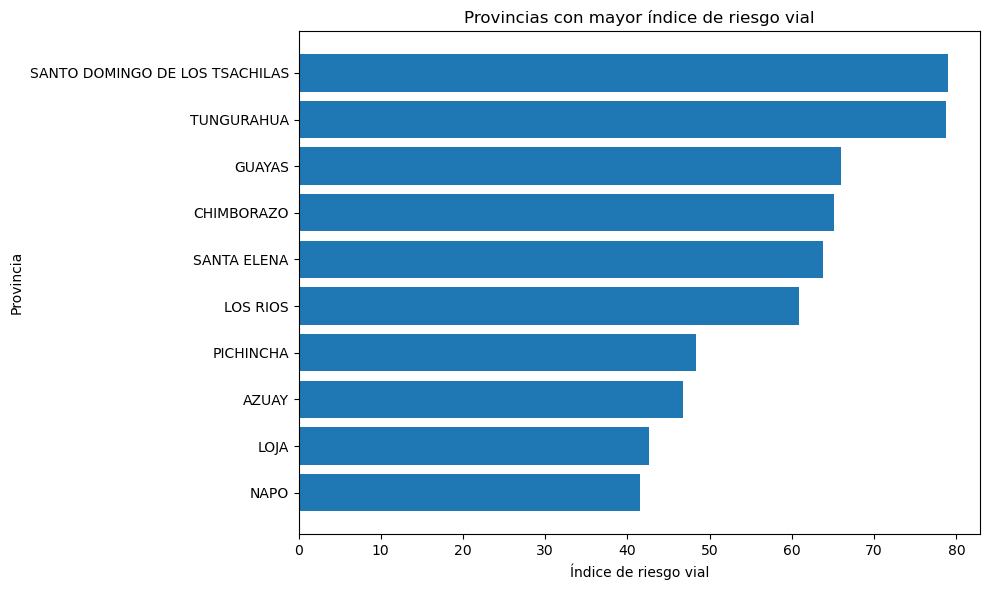

In [51]:
# GRÁFICO: ÍNDICE DE RIESGO VIAL

top_riesgo = riesgo_provincia.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_riesgo["provincia"],
    top_riesgo["indice_riesgo_vial"]
)

plt.title("Provincias con mayor índice de riesgo vial")
plt.xlabel("Índice de riesgo vial")
plt.ylabel("Provincia")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    FIGURES / "indice_riesgo_vial.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
riesgo_provincia.to_csv(
    PROCESSED / "riesgo_provincia.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tablas resumidas del EDA exportadas correctamente.")

Tablas resumidas del EDA exportadas correctamente.
